In [1]:
# import general libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy.optimize import fsolve
import os
# import own functions
from agent_game_sim import reward_matrix_for_two_player_MP # Matching Pennies
from agent_game_sim import reward_matrix_for_two_player_SH # Stag Hunt
from agent_game_sim import reward_matrix_for_two_player_BS # Bach or Stravinsky (Battle of the Sexes)
from agent_game_sim import get_individual_matrices
from agent_game_sim import generate_q_values

# Set a fixed random seed for reproducibility
np.random.seed(40)

# Deterministic Plots

In [2]:
class DeterministicAgent():
    def __init__(self, Q_values_initial, learning_rate, discount_factor, temperature):
        self.Q_values_initial = Q_values_initial
        self.Q_values = Q_values_initial
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.temperature = temperature
        self.Q_values_history = []         # history of Q-values
        self.prob_vector_history = []        # history of probabilities

    def get_prob_vector(self):
        return np.exp(self.Q_values / self.temperature) / np.sum(np.exp(self.Q_values / self.temperature))
    
    def update_history(self):
        self.Q_values_history.append(self.Q_values)
        self.prob_vector_history.append(self.get_prob_vector())

    def reset(self):
        self.Q_values = self.Q_values_initial

def deterministic_QL_step(agents, reward_matrices):
    '''Deterministic Q-learning step for a 2x2 repeated normal-form game for two agents'''
    # update history
    for agent in agents:
        agent.update_history()

    # get the probability vector of the agents
    agent_1, agent_2 = agents
    prob_vector_agent_1 = agent_1.get_prob_vector()
    prob_vector_agent_2 = agent_2.get_prob_vector()

    # get the reward matrices
    reward_matrix_A, reward_matrix_B = reward_matrices
    
    # update the Q-values via deterministic equation
    Q_vector_new_1 = agent_1.Q_values + agent_1.learning_rate * prob_vector_agent_1 * (reward_matrix_A @ prob_vector_agent_2 + agent_1.discount_factor * np.max(agent_1.Q_values) - agent_1.Q_values)
    Q_vector_new_2 = agent_2.Q_values + agent_2.learning_rate * prob_vector_agent_2 * (prob_vector_agent_1 @ reward_matrix_B + agent_2.discount_factor * np.max(agent_2.Q_values) - agent_2.Q_values)

    # update the Q-values
    agent_1.Q_values = Q_vector_new_1
    agent_2.Q_values = Q_vector_new_2

def plot_deterministic_dynamics(individual_reward_matrices, first_action_title, num_time_steps, base_value, game_title_short,
                                 learning_rate=0.01, discount_factor=0., temperature=1.,
                                 initial_probability_pairs=[], figsize=(4,4), dpi=300,
                                 SAVE_FIGURES=False, directory_for_figures='',
                                 plot_time_evolution=True, plot_colorbar=True, verbose=False):
    """
    Plot the dynamics of deterministic Q-learning in policy space for a 2x2 game.
    
    Parameters
    ----------
    individual_reward_matrices : list of np.ndarray
        List containing [reward_matrix_A, reward_matrix_B] for the two agents.
    first_action_title : str
        Label for the first action (e.g., 'Heads', 'Cooperation', 'Bach').
    num_time_steps : int
        Number of time steps to simulate.
    base_value : float
        Base value for Q-value initialization.
    game_title_short : str
        Short title for the game (used in filename).
    learning_rate : float, optional
        Learning rate for Q-learning (default: 0.01).
    discount_factor : float, optional
        Discount factor for Q-learning (default: 0).
    temperature : float, optional
        Temperature for softmax policy (default: 1).
    initial_probability_pairs : list of tuples, optional
        List of (p1, p2) initial probability pairs (default: notebook global).
    figsize : tuple, optional
        Figure size (default: notebook global).
    dpi : int, optional
        Figure resolution (default: notebook global).
    SAVE_FIGURES : bool, optional
        Whether to save the figure (default: notebook global).
    directory_for_figures : str, optional
        Directory for saving figures (default: notebook global).
    plot_time_evolution : bool, optional
        Whether to plot time evolution with color gradient (default: True).
    
    Returns
    -------
    fig : matplotlib.figure.Figure
        The generated figure.
    """
    fig = plt.figure(figsize=figsize, dpi=dpi)
    marker_size = 100
    color_start_scatter = plt.cm.plasma(0.0)
    color_end_scatter = 'red'
    
    for i, initial_probability_pair in enumerate(initial_probability_pairs):
        # Generate initial Q-values from initial probabilities
        Q_values_initial_list = [generate_q_values(probability, temperature, base_value) 
                                  for probability in initial_probability_pair]

        # Define the agents
        agents = [DeterministicAgent(Q_values_initial, learning_rate, discount_factor, temperature) 
                  for Q_values_initial in Q_values_initial_list]
        
        # Run deterministic Q-learning model
        for time_step in range(num_time_steps):
            deterministic_QL_step(agents, individual_reward_matrices)
        if verbose:
            print(f"Run finished for initial probability pair {initial_probability_pair} "
                  f"Progress: {i+1}/{len(initial_probability_pairs)}")

        # Plot only every n-th time step to reduce the number of lines
        n = 10
        prob_first_action_of_agent_1_list = [vector[0] for vector in agents[0].prob_vector_history[::n]]
        prob_first_action_of_agent_2_list = [vector[0] for vector in agents[1].prob_vector_history[::n]]
        prob_first_action_list = np.array([prob_first_action_of_agent_1_list, prob_first_action_of_agent_2_list]).T

        if plot_time_evolution:
            # Create line segments for color gradient
            lines = [[prob_first_action_list[j], prob_first_action_list[j+1]] for j in range(len(prob_first_action_list)-1)]
            lc = LineCollection(lines, cmap='plasma', linewidths=2, alpha=1)
            lc.set_array(np.linspace(0, 1, len(prob_first_action_list)))
            plt.gca().add_collection(lc)

            # Add colorbar only once (for the first trajectory)
            if plot_colorbar and i == 0:
                cbar = plt.colorbar(lc, fraction=0.046, pad=0.04)
                cbar.set_label('time steps', labelpad=-20, y=0.5)
                tick_values = [0, 1]
                cbar.set_ticks(tick_values)
                tick_labels = [0, num_time_steps]
                def custom_formatter(x):
                    return f'{x:.0e}'.replace('e+0', 'e+').replace('e-0', 'e-')
                tick_labels_formatted = [custom_formatter(t) for t in tick_labels]
                cbar.set_ticklabels(tick_labels_formatted)
        else:
            plt.plot(prob_first_action_list[:, 0], prob_first_action_list[:, 1], alpha=1)

        # Plot start and end points
        plt.scatter(prob_first_action_list[0, 0], prob_first_action_list[0, 1], marker='+', 
                    color=color_start_scatter, zorder=10, s=marker_size)
        plt.scatter(prob_first_action_list[-1, 0], prob_first_action_list[-1, 1], marker='x', 
                    color=color_end_scatter, zorder=10, s=marker_size)

    # Add plot cosmetics
    fontsize = None
    title = r'$Q_{base} =$' + f'{base_value:.1f}, ' + f'$\\gamma$ = {discount_factor}'
    plt.title(title, wrap=True, horizontalalignment='center', fontsize=fontsize)
    plt.xlabel(f'Policy of Agent 1, $\\pi^1_{{{first_action_title}}}$', fontsize=fontsize)
    plt.ylabel(f'Policy of Agent 2, $\\pi^2_{{{first_action_title}}}$', fontsize=fontsize)
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.xlim(-0.01, 1.01)
    plt.ylim(-0.01, 1.01)
    plt.grid()
    ax = plt.gca()
    ax.set_aspect('equal', adjustable='box')

    # Save figure
    if SAVE_FIGURES:
        filename = (f'Fig3_{game_title_short}_DeterministicDynamics_discount_{discount_factor}_'
                    f'Qbase_{base_value}_temp_{temperature}_learningRate_{learning_rate}_'
                    f'numTimeSteps_{num_time_steps}.jpg')
        plt.savefig(os.path.join(directory_for_figures, filename), dpi=dpi, bbox_inches='tight')
    
    plt.show()
    return fig

In [3]:
# Plotting settings
directory_for_figures = 'PaperFigures' # directory for saving the figures
if not os.path.exists(directory_for_figures):
    os.makedirs(directory_for_figures)
figsize = (4, 4)
dpi = 100
SAVE_FIGURES = True

# Set the parameter arrays for the different games
reward_function_array = [reward_matrix_for_two_player_MP, reward_matrix_for_two_player_SH, reward_matrix_for_two_player_BS]
game_title_short = ['MP', 'SH', 'BS']
game_title = ['Matching Pennies', 'Stag Hunt', 'Bach or Stravinsky']
first_action_title = ['H', 'C', 'B']
individual_reward_matrices_array = [get_individual_matrices(reward_function) for reward_function in reward_function_array]

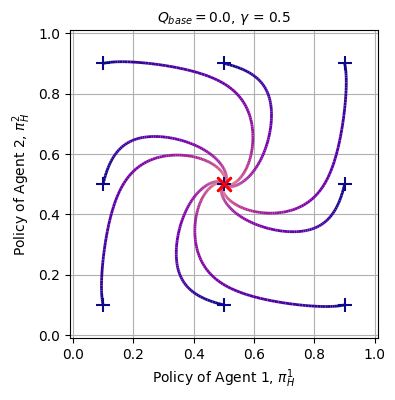

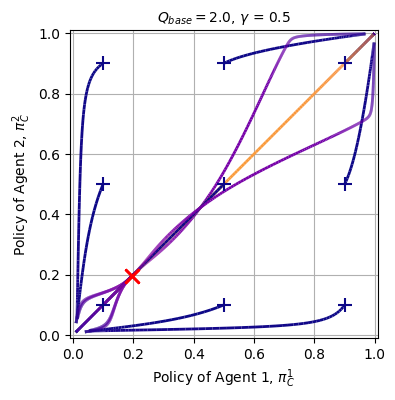

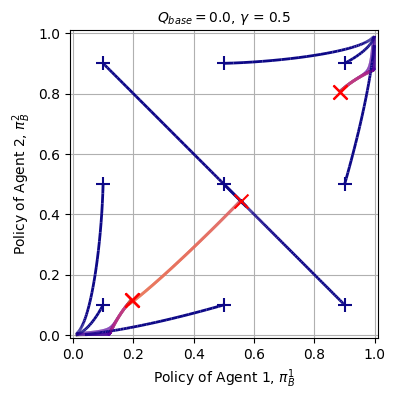

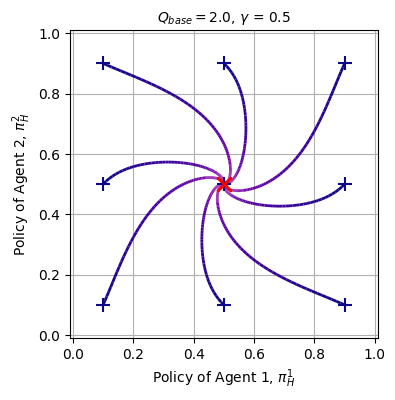

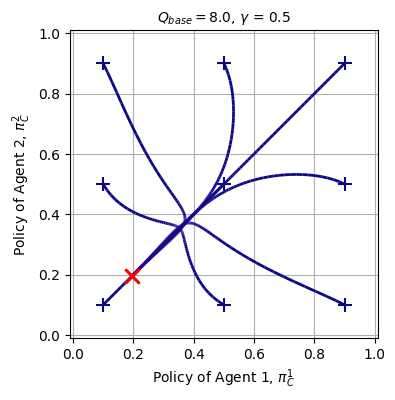

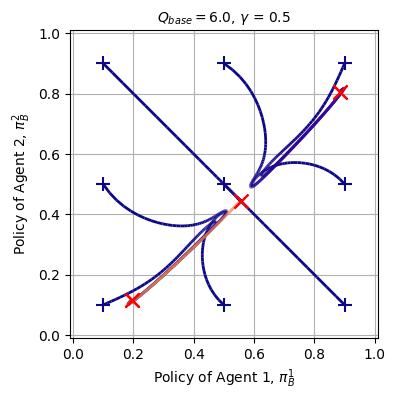

In [4]:
# simulation parameters
initial_probability_pairs = [(0.1, 0.9), (0.5, 0.9), (0.9, 0.9),
                        (0.1, 0.5), (0.5, 0.5), (0.9, 0.5),
                        (0.1, 0.1), (0.5, 0.1), (0.9, 0.1)]
#initial_probability_pairs = [(0.1, 0.9)]

# Define learning parameters
learning_rate = 0.01
discount_factor = 0.5
temperature = 1

num_time_steps_array = [int(2e3), int(2.5e4), int(4e4)]
base_value_min_array = [np.min(individual_reward_matrices) for individual_reward_matrices in individual_reward_matrices_array] # minimal reward value in the reward matrices
base_value_max_array = [np.max(individual_reward_matrices) for individual_reward_matrices in individual_reward_matrices_array] # maximal reward value in the reward matrices
base_value_min_array = np.array(base_value_min_array) * 1/(1-discount_factor) 
base_value_max_array = np.array(base_value_max_array) * 1/(1-discount_factor)

# generate plots
for base_value_array in [base_value_min_array, base_value_max_array]:
    for i in range(len(game_title_short)):
        plot_deterministic_dynamics(
            individual_reward_matrices_array[i],
            first_action_title[i],
            num_time_steps_array[i],
            base_value_array[i], 
            game_title_short[i],
            learning_rate=learning_rate, 
            discount_factor=discount_factor, 
            temperature=temperature,
            initial_probability_pairs=initial_probability_pairs,
            figsize=figsize,
            dpi=dpi,
            SAVE_FIGURES=False, 
            directory_for_figures=directory_for_figures,
            plot_colorbar=False)

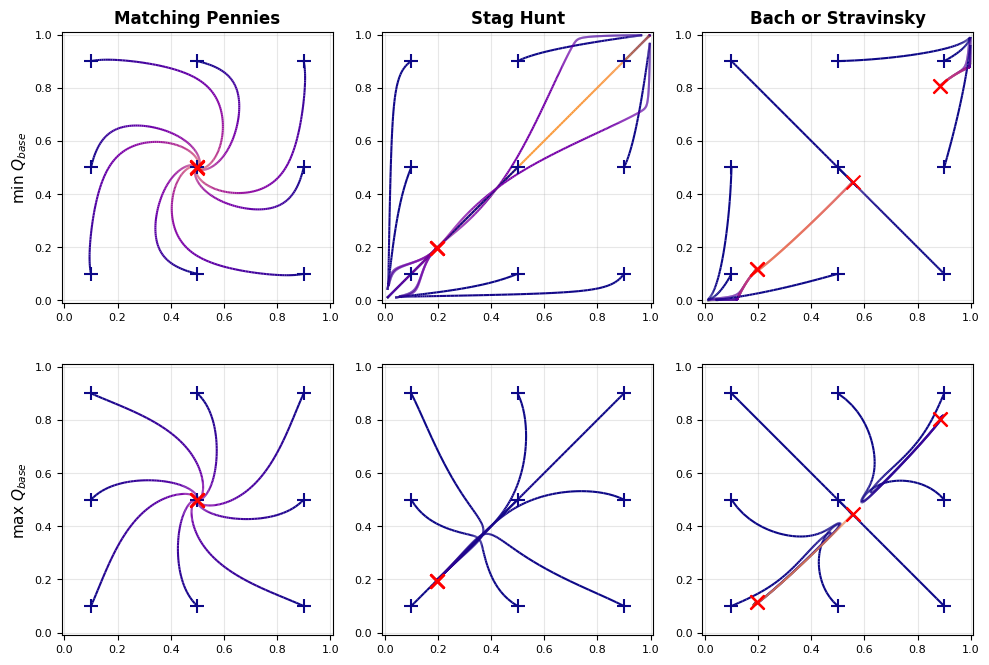

In [5]:
# Create 3x2 grid: columns = games (MP, SH, BS), rows = (min Qbase, max Qbase)
fig, axes = plt.subplots(2, 3, figsize=(10, 7), dpi=dpi)

marker_size = 100
color_start_scatter = plt.cm.plasma(0.0)
color_end_scatter = 'red'

base_value_arrays = [base_value_min_array, base_value_max_array]
row_labels = ['min $Q_{base}$', 'max $Q_{base}$']

for row_idx, base_value_array in enumerate(base_value_arrays):
    for col_idx in range(len(game_title_short)):
        ax = axes[row_idx, col_idx]
        
        individual_reward_matrices = individual_reward_matrices_array[col_idx]
        base_value = base_value_array[col_idx]
        num_time_steps = num_time_steps_array[col_idx]
        
        for initial_probability_pair in initial_probability_pairs:
            # Generate initial Q-values from initial probabilities
            Q_values_initial_list = [generate_q_values(probability, temperature, base_value) 
                                      for probability in initial_probability_pair]

            # Define the agents
            agents = [DeterministicAgent(Q_values_initial, learning_rate, discount_factor, temperature) 
                      for Q_values_initial in Q_values_initial_list]
            
            # Run deterministic Q-learning model
            for time_step in range(num_time_steps):
                deterministic_QL_step(agents, individual_reward_matrices)

            # Plot only every n-th time step to reduce the number of lines
            n = 10
            prob_first_action_of_agent_1_list = [vector[0] for vector in agents[0].prob_vector_history[::n]]
            prob_first_action_of_agent_2_list = [vector[0] for vector in agents[1].prob_vector_history[::n]]
            prob_first_action_list = np.array([prob_first_action_of_agent_1_list, prob_first_action_of_agent_2_list]).T

            # Create line segments for color gradient
            lines = [[prob_first_action_list[j], prob_first_action_list[j+1]] for j in range(len(prob_first_action_list)-1)]
            lc = LineCollection(lines, cmap='plasma', linewidths=1.5, alpha=1)
            lc.set_array(np.linspace(0, 1, len(prob_first_action_list)))
            ax.add_collection(lc)

            # Plot start and end points
            ax.scatter(prob_first_action_list[0, 0], prob_first_action_list[0, 1], marker='+', 
                        color=color_start_scatter, zorder=10, s=marker_size)
            ax.scatter(prob_first_action_list[-1, 0], prob_first_action_list[-1, 1], marker='x', 
                        color=color_end_scatter, zorder=10, s=marker_size)

        # Subplot cosmetics
        ax.set_xlim(-0.01, 1.01)
        ax.set_ylim(-0.01, 1.01)
        ax.set_aspect('equal', adjustable='box')
        ax.grid(True, alpha=0.3)
        ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        ax.tick_params(labelsize=8)
        
        # Column titles (game names) - only on top row
        if row_idx == 0:
            ax.set_title(game_title[col_idx], fontsize=12, fontweight='bold')
        
        # Row labels - only on leftmost column
        if col_idx == 0:
            ax.set_ylabel(row_labels[row_idx], fontsize=11)

plt.tight_layout()

if SAVE_FIGURES:
    filename = f'Fig3_AllGames_DeterministicDynamics_discount_{discount_factor}_temp_{temperature}_learningRate_{learning_rate}.jpg'
    plt.savefig(os.path.join(directory_for_figures, filename), dpi=dpi, bbox_inches='tight')

plt.show()

Run finished for initial probability pair (0.9, 0.1) Progress: 3/9


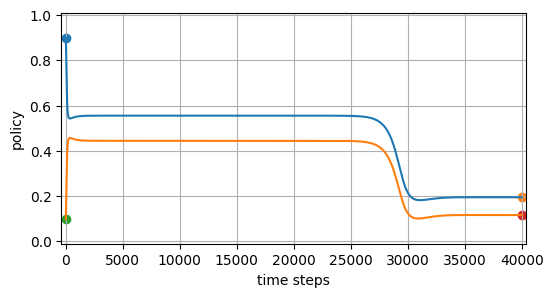

In [6]:
initial_probability_pair = (0.9,0.1)
discount_factor = 0.5
base_value = 3 * 1/(1-discount_factor )
num_time_steps = int(4e4)
individual_reward_matrices = get_individual_matrices(reward_matrix_for_two_player_BS)

# Generate initial Q-values from initial probabilities
Q_values_initial_list = [generate_q_values(probability, temperature, base_value) 
                            for probability in initial_probability_pair]

# Define the agents
agents = [DeterministicAgent(Q_values_initial, learning_rate, discount_factor, temperature) 
            for Q_values_initial in Q_values_initial_list]

# Run deterministic Q-learning model
for time_step in range(num_time_steps):
    deterministic_QL_step(agents, individual_reward_matrices)
print(f"Run finished for initial probability pair {initial_probability_pair} "
        f"Progress: {i+1}/{len(initial_probability_pairs)}")
    
# Plot only every n-th time step to reduce the number of lines
n = 1
prob_first_action_of_agent_1_list = [vector[0] for vector in agents[0].prob_vector_history[::n]]
prob_first_action_of_agent_2_list = [vector[0] for vector in agents[1].prob_vector_history[::n]]

fig = plt.figure(figsize=(6,3), dpi=dpi)
plt.plot(prob_first_action_of_agent_1_list)
plt.scatter(0, prob_first_action_of_agent_1_list[0])
plt.scatter(num_time_steps, prob_first_action_of_agent_1_list[-1])
# second agent
plt.plot(prob_first_action_of_agent_2_list)
plt.scatter(0, prob_first_action_of_agent_2_list[0])
plt.scatter(num_time_steps, prob_first_action_of_agent_2_list[-1])
# cosmetics
plt.xlim(0,num_time_steps)
plt.xlim(-num_time_steps/100,num_time_steps+num_time_steps/100)
plt.ylim(-0.01,1.01)
plt.xlabel('time steps')
plt.ylabel('policy')
plt.grid()